# Набор данных о Продажах машин

В наборе данных содержится **140,904** записей с **12** признаками. Задачей является предсказание **цены (`Price`)** машины на основании имеющихся признаков.



## Описание признаков

| Имя признака    | Тип данных     | Описание                                                                          |
| --------------- | -------------- | --------------------------------------------------------------------------------- |
| `Brand`         | Категориальный | Производитель автомобиля (к примеру, Honda, Toyota, BMW)                          |
| `Model_Name`    | Категориальный | Название модели автомобиля                                                        |
| `Model_Variant` | Категориальный | Комплектация автомобиля                                                           |
| `Car_Type`      | Категориальный | Тип кузова автомобиля                                                            |
| `Transmission`  | Категориальный | Ручная или автоматическая коробка передач                                         |
| `Fuel_Type`     | Категориальный | Тип топлива                                                                       |
| `Year`          | Числовой       | Год производства автомобиля                                                       |
| `Kilometers`    | Числовой       | Пробег автомобиля                                                                 |
| `Owner`         | Ординальный    | Сколько было владельцев у автомобиля (1,2, или 3 и больше)                        |
| `State`         | Категориальный | Регион Индии, где автомобиль выставлен на продажу                                 |
| `Accidental`    | Категориальный | Участвовал ли автомобиль в аварии (да/нет)                                        |
| `Price`         | Числовой       | **Целевой признак**. Цена автомобиля в Индийских рупиях                           |


In [1]:
import numpy as np
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RANSACRegressor, TheilSenRegressor
import warnings
warnings.filterwarnings("ignore")


Загрузим набор данных и отобразим основную информацию:

In [2]:

df = pd.read_csv('./Car Sell Dataset.csv')


print("Размер набора данных:", df.shape)
print("\nТипы данных и количество пропусков:")
print(df.info())

Размер набора данных: (140904, 12)

Типы данных и количество пропусков:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140904 entries, 0 to 140903
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Brand          140904 non-null  object
 1   Model Name     140904 non-null  object
 2   Model Variant  140904 non-null  object
 3   Car Type       140904 non-null  object
 4   Transmission   140904 non-null  object
 5   Fuel Type      140904 non-null  object
 6   Year           140904 non-null  int64 
 7   Kilometers     140904 non-null  int64 
 8   Owner          140904 non-null  object
 9   State          140904 non-null  object
 10  Accidental     140904 non-null  object
 11  Price          140904 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 12.9+ MB
None


In [3]:
print("Пропущенные даные:\n", df.isnull().sum())

Пропущенные даные:
 Brand            0
Model Name       0
Model Variant    0
Car Type         0
Transmission     0
Fuel Type        0
Year             0
Kilometers       0
Owner            0
State            0
Accidental       0
Price            0
dtype: int64


In [4]:
print("Первые 5 строк:")
df.head()

Первые 5 строк:


,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Year,Kilometers,Owner,State,Accidental,Price
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,2017,164654,1st,Rajasthan,No,547253
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,2018,41351,1st,Maharashtra,No,512050
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,2002,119090,3rd+,Tamil Nadu,No,678923
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,2013,19979,1st,Andhra Pradesh,No,522500
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,2011,130591,3rd+,Bihar,No,401182


## Обработка данных

In [5]:
sz1 = len(df)
# Удаление дубликатов (если есть)
df.drop_duplicates(inplace=True)
print(f"Удалено {sz1 - len(df)} записей.")

# Переименование столбцов (замена пробелов)
df.columns = [col.strip().replace(' ', '_') for col in df.columns]

print("Новые имена столбцов:")
print(df.columns)


Удалено 0 записей.
Новые имена столбцов:
Index(['Brand', 'Model_Name', 'Model_Variant', 'Car_Type', 'Transmission',
       'Fuel_Type', 'Year', 'Kilometers', 'Owner', 'State', 'Accidental',
       'Price'],
      dtype='object')


## Извлечение признаков

In [6]:
# Из года производства можно получить "возраст" машины, намного более полезный признак
df['Car_Age'] = 2024 - df['Year']
df.drop(columns=['Year'], inplace=True)

In [7]:
# Формируем выборки
X = df.drop(columns=["Price"])
Y = df["Price"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=51, test_size=0.2)

Перед применением моделей также взглянем на распределения величин

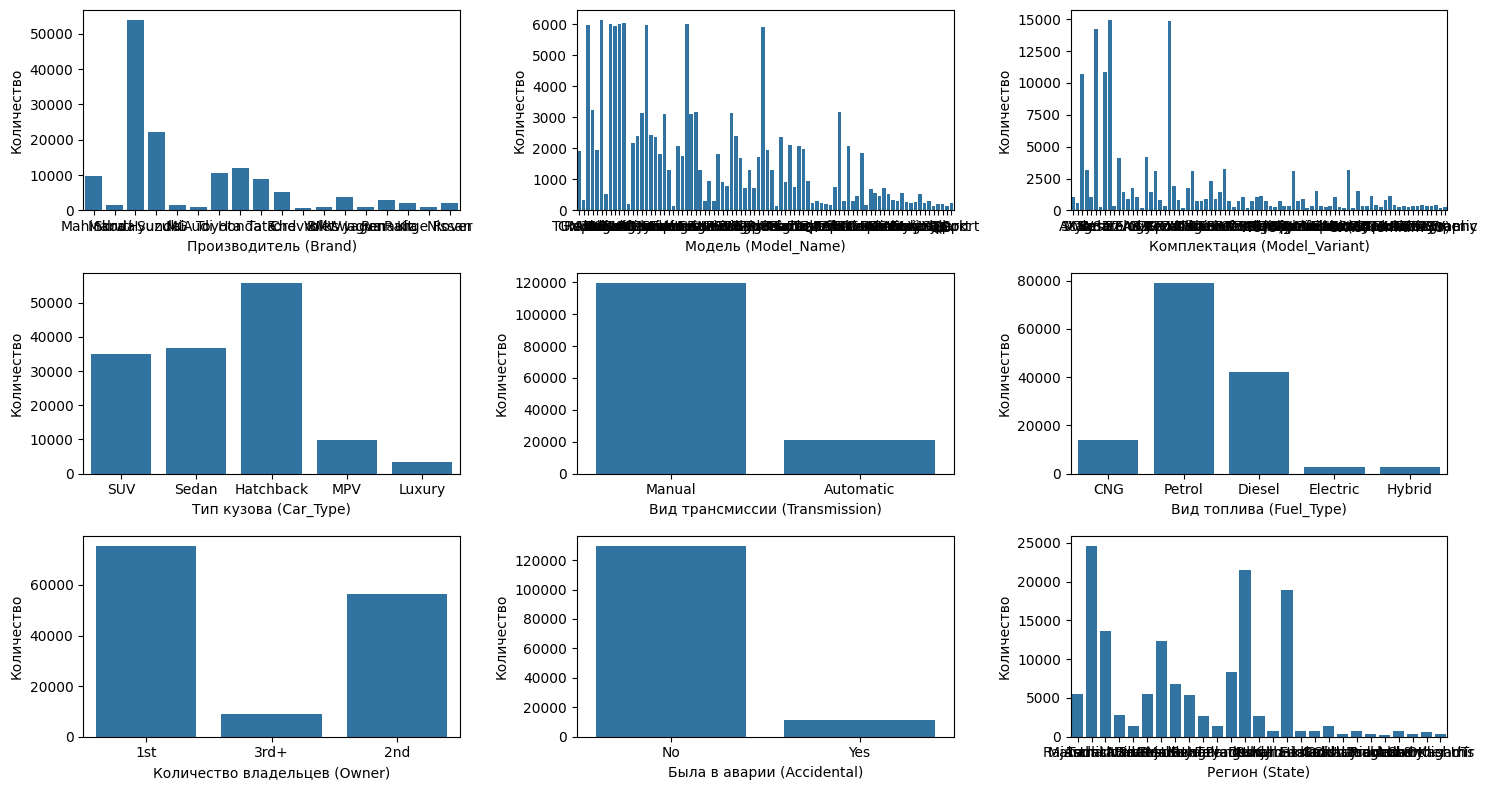

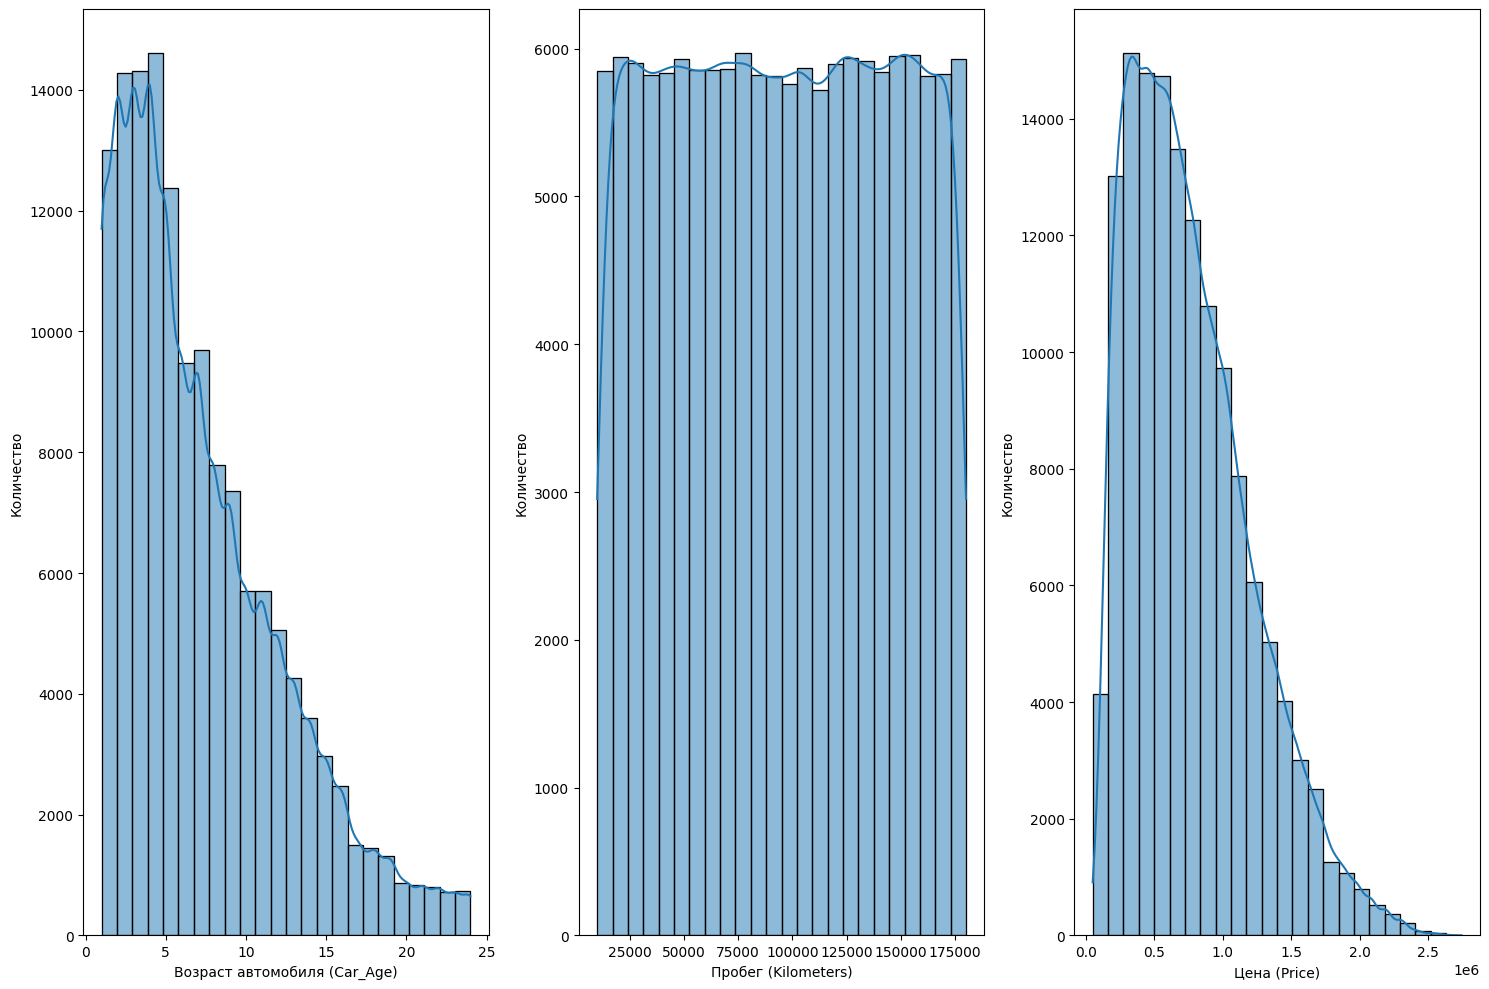

In [8]:

categorical_columns = [ 
    ("Brand", "Производитель"),
    ("Model_Name", "Модель"),
    ("Model_Variant", "Комплектация"),
    ("Car_Type", "Тип кузова"),    
    ("Transmission", "Вид трансмиссии"),
    ("Fuel_Type", "Вид топлива"),
    ("Owner", "Количество владельцев"),
    ("Accidental", "Была в аварии"),
    ("State", "Регион"),
]

numerical_columns = [
    ("Car_Age", "Возраст автомобиля"),
    ("Kilometers", "Пробег"),
    ("Price", "Цена"),
]


fig, axes = plt.subplots(3, 3)
fig.set_size_inches(15, 8)
axes = axes.flatten()
for index, column in enumerate(categorical_columns):
    sns.countplot(data=df, x=column[0], ax=axes[index])
    axes[index].set_xlabel(f"{column[1]} ({column[0]})")
    axes[index].set_ylabel("Количество")
fig.tight_layout()

fig, axes = plt.subplots(1, 3)
fig.set_size_inches(15,10)
axes = axes.flatten()
for index, column in enumerate(numerical_columns):
    sns.histplot(data=df, x=column[0], kde=True, bins=24, ax=axes[index])
    axes[index].set_xlabel(f"{column[1]} ({column[0]})")
    axes[index].set_ylabel("Количество")
fig.tight_layout()

Некоторые графики с категориями получились немного смазанными из-за большого количества категорий. 

Тем не менее можно заметить некоторые интересные закономерности в данных: 

- Распределение пробега автомобилей равномерное.
- Распределение цены и возраста автомобиля похоже Гамма-распределение, хотя как уже наверняка отмечалось на лекциях, любое распределение с одним куполом, определённое на положительных значениях, скорее всего будет неплохо описываться гамма-распределением.

<b>Опишем основные виды столбцов для их последующего преобразования:</b>

In [9]:
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder, OneHotEncoder, LabelEncoder, LabelBinarizer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Категориальные признаки с большим количеством значений
categorical_big_cols = ['Brand', 'Model_Name', 'Model_Variant']

# Ординальный признак и порядок значений
ordinal_columns = ['Owner']
ordinals_order = [["1st", "2nd", "3rd+"]]

# Категориальные столбцы
categorical_columns = ['Car_Type', 'Transmission', 'Fuel_Type', 'State', 'Accidental']

numerical_columns = ["Kilometers", "Car_Age"]


## Первый вариант кодирования категориальных признаков

Там, откуда взят набор данных многие пользователи применяют следующее преобразование данных:

In [10]:
# Encode categorical features
cat_cols = ['Brand', 'Model_Name', 'Model_Variant', 'Car_Type',
            'Transmission', 'Fuel_Type', 'Owner', 'State', 'Accidental']

X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()
le = LabelEncoder()
for col in cat_cols:
    X_train_transformed[col] = le.fit_transform(X_train_transformed[col])
    X_test_transformed[col] = le.transform(X_test_transformed[col])

Что в этом плохого? 

А то, что все категориальные столбы просто преобразуются в числа от 0 до {количества категорий}-1.

Но проблема в том, что линейная регрессия строит именно линейную зависимость, а при таком представлении никакой линейной зависимости от данных явно нет. Зато полученные данные выглядят красиво. Всего 11 столбцов и всё имеет числовой вид:

In [11]:
X_train_transformed

,Brand,Model_Name,Model_Variant,Car_Type,Transmission,Fuel_Type,Kilometers,Owner,State,Accidental,Car_Age
62830,5,83,46,0,1,1,145257,1,26,0,2
116540,13,38,41,3,1,0,132864,1,5,0,1
104188,15,67,78,4,1,4,152624,1,11,0,7
14893,9,13,66,3,1,1,169510,1,23,0,1
101951,10,16,8,0,1,1,170482,2,5,0,10
...,...,...,...,...,...,...,...,...,...,...,...
70266,5,82,46,0,0,4,15238,1,22,0,11
23461,5,82,6,0,1,4,164745,2,5,0,12
17844,3,29,60,4,1,1,101915,2,13,0,14
100409,15,5,78,0,0,4,171969,1,12,0,3


In [12]:
# Cтандартизация признаков
stand_scaler = StandardScaler()
X_train_transformed = stand_scaler.fit_transform(X_train_transformed)
X_test_transformed = stand_scaler.transform(X_test_transformed)

Такие данные плохо подойдут для применения линейной регрессии, зато хорошо подойдут для <b>деревьев принятия решений</b>. Пока подробно рассматривать это семейство моделей машинного обучения не будем, но мы рассмотрим её на нашем курсе позже, а пока просто применим готовую реализацию.

In [13]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor

models = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    # Варианты решающих деревьев
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=50, random_state=537),
    "Random Forest": RandomForestRegressor(n_estimators=30, random_state=537),
    "AdaBoost": AdaBoostRegressor(n_estimators=50, random_state=537),
}

results = {}
for name, model in models.items():
    model.fit(X_train_transformed, Y_train)
    Y_train_pred = model.predict(X_train_transformed)
    Y_test_pred = model.predict(X_test_transformed)
    mse = root_mean_squared_error(Y_test, Y_test_pred)
    r2 = r2_score(Y_test, Y_test_pred)
    r2_train = r2_score(Y_train, Y_train_pred)
    results[name] = {"RMSE": mse, "R2 Score Train": r2_train, "R2 Score": r2}

results_df = pd.DataFrame(results).T.sort_values(by="R2 Score", ascending=False)
results_df 

,RMSE,R2 Score Train,R2 Score
Gradient Boosting,363915.693828,0.318018,0.321927
AdaBoost,371921.403435,0.287453,0.291765
Random Forest,382092.408283,0.887577,0.252499
Ridge Regression,382331.169707,0.249276,0.251565
Linear Regression,382331.184323,0.249276,0.251565
Lasso Regression,382331.193141,0.249276,0.251565


Как мы видим, на таких данных решающие деревья и правда обходят методы линейной регрессии, правда результаты тоже не самые впечатляющие. Разброс в 300000 при ценах около миллиона не слишком воодушевляют.

Теперь же попробуем более качественно подготовить признаки.

## Второй вариант кодирования признаков

In [14]:

tranformer = ColumnTransformer(transformers=[
    ("categorical", OneHotEncoder(drop="first"), categorical_columns),
    ("cat", OneHotEncoder(drop="first"), categorical_big_cols),
    ("ordinal", OrdinalEncoder(categories=ordinals_order), ordinal_columns),
    ("numeric", StandardScaler(), numerical_columns),
],
remainder="drop")# Остальные столбцы отбрасываются

In [15]:
X_train_transformed = tranformer.fit_transform(X_train)
X_test_transformed = tranformer.transform(X_test)

In [16]:
X_train_transformed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 999122 stored elements and shape (112723, 220)>

Теперь в преобразованных данных будет уже не 11 столбцов, а 220, зато они позволят обучить линейные модели. Мы исключим Решающие деревья. Из-за большого количества признаков их обучение займёт слишком много времени, а более качественных результатов на решающих деревьях мы не получим.

In [17]:
Y_test_transformed = Y_test
Y_train_transformed = Y_train

In [18]:
models = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Lasso Regression": Lasso(),
    "Ridge Regression": Ridge(),
}

results = {}
for name, model in models.items():
    model.fit(X_train_transformed, Y_train_transformed)
    
    Y_train_pred = model.predict(X_train_transformed)
    Y_test_pred = model.predict(X_test_transformed)
    
    mse = root_mean_squared_error(Y_test_transformed, Y_test_pred)
    r2 = r2_score(Y_test_transformed, Y_test_pred)
    r2_train = r2_score(Y_train_transformed, Y_train_pred)
    
    results[name] = {"RMSE": mse, "R2 Score Train": r2_train, "R2 Score": r2}

results_df = pd.DataFrame(results).T.sort_values(by="R2 Score", ascending=False)
results_df 

,RMSE,R2 Score Train,R2 Score
Lasso Regression,376432.060708,0.277344,0.274482
Ridge Regression,376434.341092,0.277344,0.274473
Linear Regression,376436.677075,0.277345,0.274464


И так мы получили снова не впечатляющий результат, но это уже лучше.

Иногда полезно посмотреть на разброс настоящих значений и предсказанных моделью. По получаемой форме можно также оценить работу модели и найти некоторые проблемы. По оси X мы отобразили предсказанные значения, а по оси Y действительные. 

В идеале мы бы хотели увидеть между ними линейную зависимость. 

Что сразу бросается в глаза - иногда модель предсказывает отрицательные значения. Но цена не может быть отрицательной, это хотелось бы как-то исправить.  

Также оказывается, что модель для разных цен ошибается по разному чем больше предсказание модели, тем больше разброс действительных значений.

Но важно заметить, что получаемое облако всё-же довольно вытянутое, то есть у модели что-то получается предсказывать, но плохо.

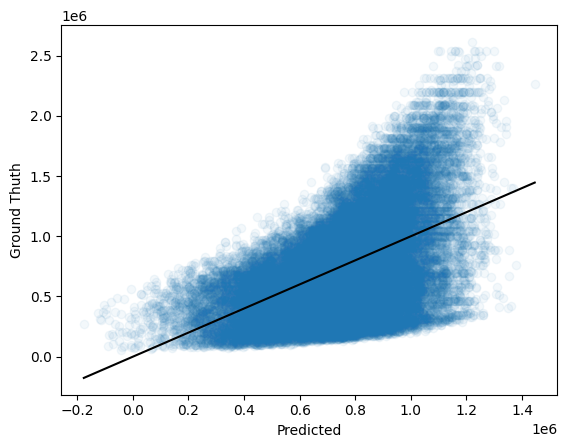

In [19]:

plt.scatter(Y_test_pred, Y_test, alpha=0.05)
plt.xlabel("Predicted")
plt.ylabel("Ground Thuth")


t = np.linspace(Y_test_pred.min(), Y_test_pred.max(),100)

plt.plot(t,t,color="black")

Распределение ошибок. Оно имеет колоколообразное распределение, но оно сильно скошено.

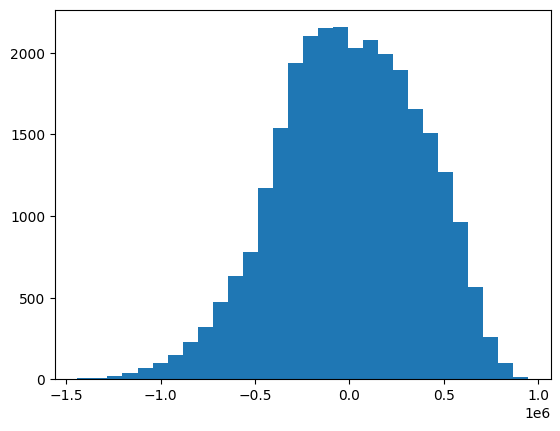

In [20]:
plt.hist(Y_test_pred - Y_test_transformed, bins = 30)
plt.show()

## Логарифмирование целевой переменной

Описанная проблема того, что целевая переменная имеет положительные значения, а модель может предсказывать любые,  является довольно распространённой. Такие данные встречаются очень часто. 

Касательно цен, зарплат и всего, что связано с деньгами добавляется ещё другое свойство: Шум, накладываемый на данные зависит от значения целевой переменной. 

Получается, что просто невозможно обучить модель, которая предсказывала бы цену с фиксированным разбросом, потому что сам шум в данных не фиксированный.

Принято для цен извлекать логарифм и ошибку тоже считать от логарифма цен. Это переводит ошибку, зависимую от значения в фиксированную ошибку.

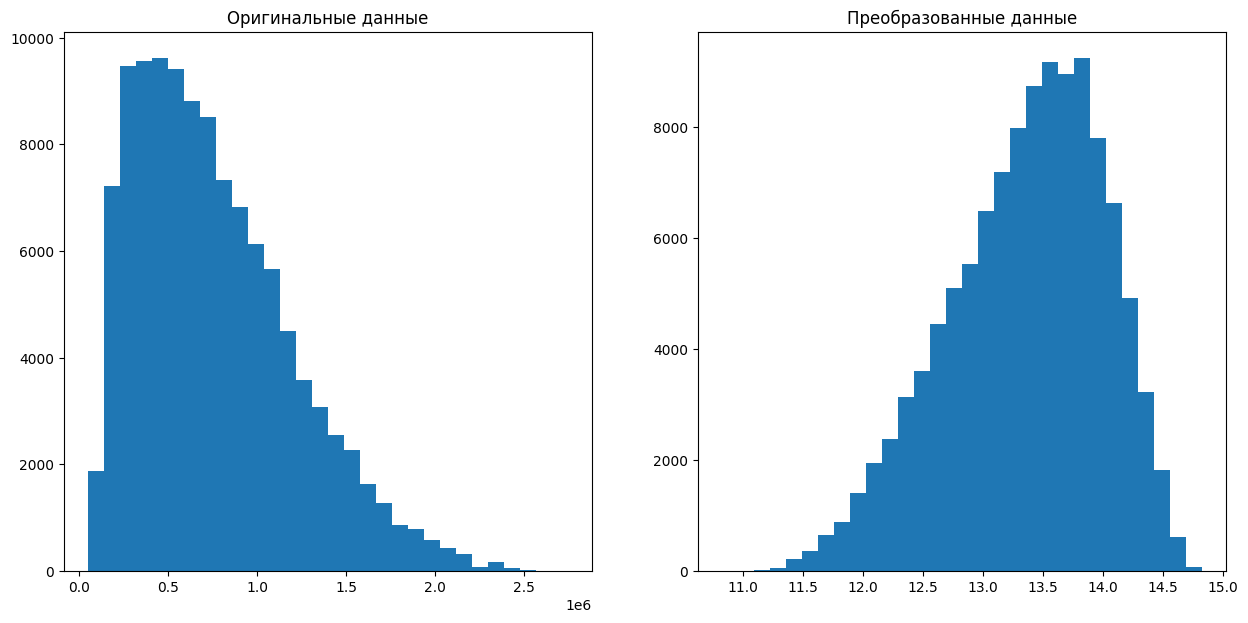

In [21]:
Y_train_transformed = np.log(Y_train)
Y_test_transformed = np.log(Y_test)

plt.subplot(121)
plt.hist(Y_train, bins=30)
plt.title("Оригинальные данные")
plt.subplot(122)
plt.hist(Y_train_transformed, bins=30)
plt.title("Преобразованные данные")
plt.gcf().set_size_inches(15,7)
plt.show()

Теперь обучим модели и оценим ошибку с помощью метрики MAPE. Важно не забывать, что метрики мы хотим посчитать не для логарифма целевой переменной, а всё же для настоящей целевой переменной.

In [22]:
from sklearn.preprocessing import PolynomialFeatures
models = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Lasso Regression": Lasso(alpha=0.01),
    "Ridge Regression": Ridge(alpha=0.01),
    "poly": make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1000)), # Большой коэффициент регуляризации для предотвращения переобучения
}   

results = {}
for name, model in models.items():
    model.fit(X_train_transformed, Y_train_transformed)
    
    Y_train_pred = model.predict(X_train_transformed)
    Y_test_pred = model.predict(X_test_transformed)

    mse = root_mean_squared_error(Y_test_transformed, Y_test_pred)
    r2 = r2_score(Y_test_transformed, Y_test_pred)
    r2_train = r2_score(Y_train_transformed, Y_train_pred)
    
    results[name] = {"RMSE": mse, "R2 Score Train": r2_train, "R2 Score": r2}

results_df = pd.DataFrame(results).T.sort_values(by="R2 Score", ascending=False)
results_df 

,RMSE,R2 Score Train,R2 Score
poly,0.551688,0.279093,0.271625
Linear Regression,0.557765,0.258236,0.255488
Ridge Regression,0.557768,0.258235,0.255481
Lasso Regression,0.566842,0.231149,0.231059


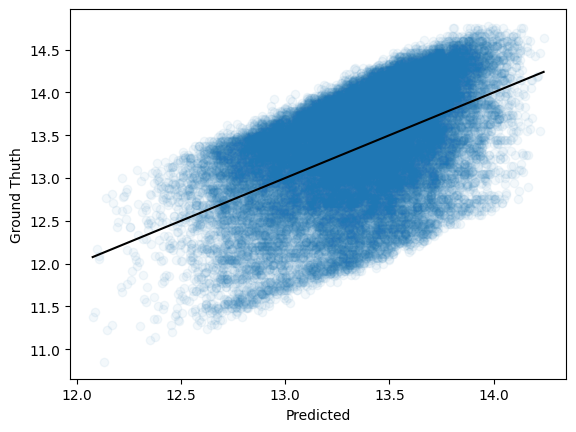

In [23]:
plt.scatter(Y_test_pred,Y_test_transformed,  alpha=0.05)
plt.xlabel("Predicted")
plt.ylabel("Ground Thuth")


t = np.linspace(Y_test_pred.min(), Y_test_pred.max(),100)

plt.plot(t,t,color="black")

# Домашнее задание


Попробуйте улучшить результаты обучения модели. 
- Поменяйте коэффициент регуляризации
- Измените методы регуляризации
- Попробуйте другие методы подготовки данных (к примеру, TargetEncoding)
- Извлеките полиномиальные признаки
- Удалите категории (замените на "другое"), имеющие малое количество объектов
